In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/Ge71_Kshell_dmcgun_10kevents/DMCOutput/Ge71_Kshell_????????_??????.root'))

In [5]:
df = CDataFrame("G4SimDir/g4dmcEvent", filepath)

In [7]:
branches = (["EventNum", "PhononE"])
df_dmc = df.AsNumpy(branches)
df_dmc["PhononEsum"] = np.array([sum(i) for i in df_dmc["PhononE"]])

Text(0, 1, 'Count / $\\mathrm{\\mu A}$')

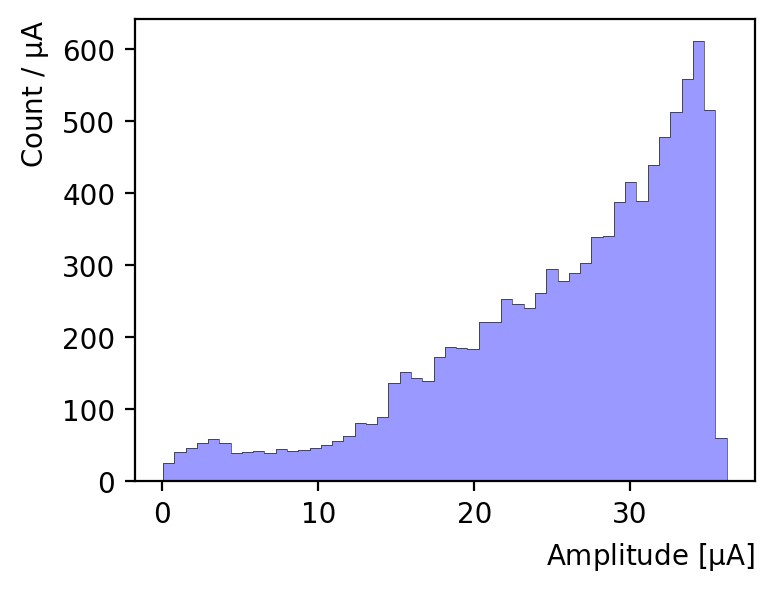

In [10]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_dmc["PhononEsum"]*1e-3, bins=50, alpha = 0.4, color = 'blue')
plt.hist(df_dmc["PhononEsum"]*1e-3, bins=50, histtype='step', color = 'black', lw = 0.2)
#plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / $\mathrm{\mu A}$")

Text(0, 1, 'Count / (0.3 $\\mathrm{\\mu A}$)')

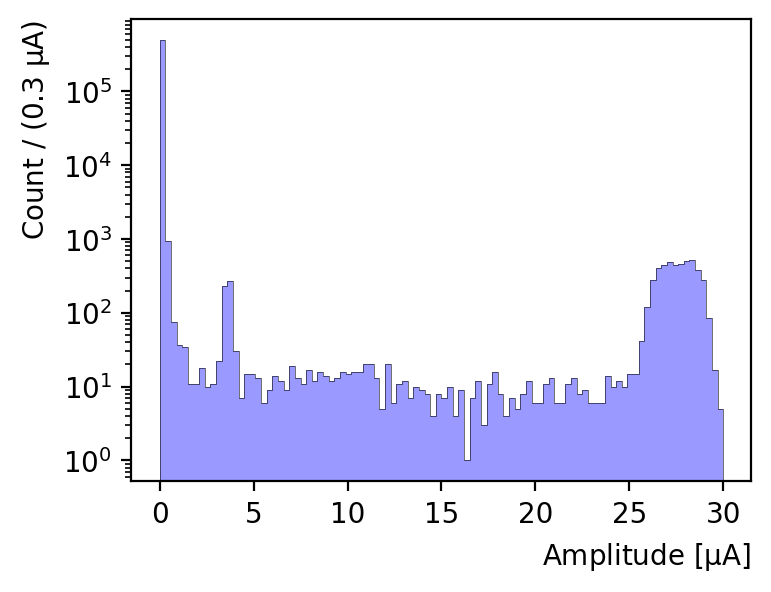

In [9]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 30, 101)
bindiff = np.round(np.diff(bins)[0], 3)
plt.hist(df_rqs['PTOFamps']*1e6, bins=bins, alpha = 0.4, color = 'blue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=bins, histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / ({}".format(bindiff) + " $\mathrm{\mu A}$)")

In [10]:
L_peak_bins = np.linspace(2.5, 5, 51)
K_peak_bins = np.linspace(24, 32, 51)
L_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 2.5e-6) & (df_rqs['PTOFamps'] <= 5e-6)] * 1e6
K_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 24e-6) & (df_rqs['PTOFamps'] <= 32e-6)] * 1e6

Text(0, 1, 'Count / (0.05 $\\mathrm{\\mu A}$)')

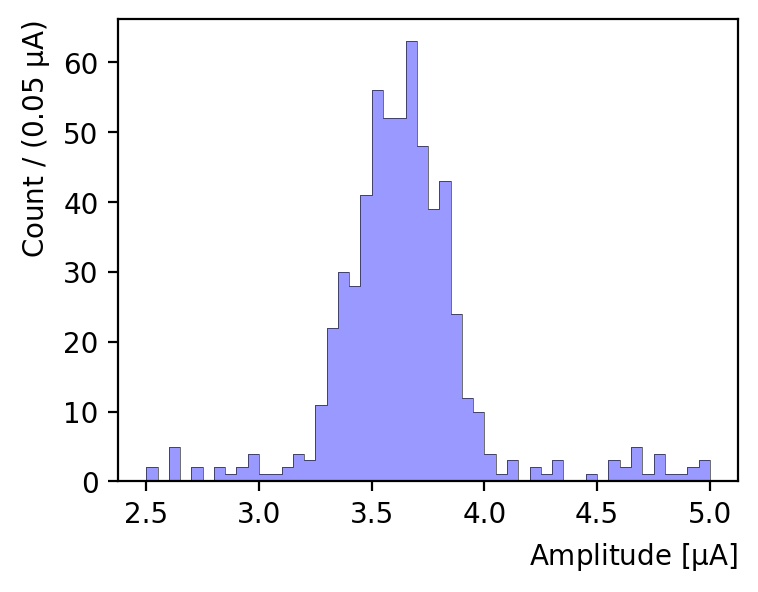

In [11]:
plt.figure(figsize=(4,3), dpi=200)
bindiff = np.round(np.diff(L_peak_bins)[0], 3)
plt.hist(L_peak_data, bins=L_peak_bins, alpha = 0.4, color = 'blue')
plt.hist(L_peak_data, bins=L_peak_bins, histtype='step', color = 'black', lw = 0.2)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / ({}".format(bindiff) + " $\mathrm{\mu A}$)")

Text(0, 1, 'Count / (0.16 $\\mathrm{\\mu A}$)')

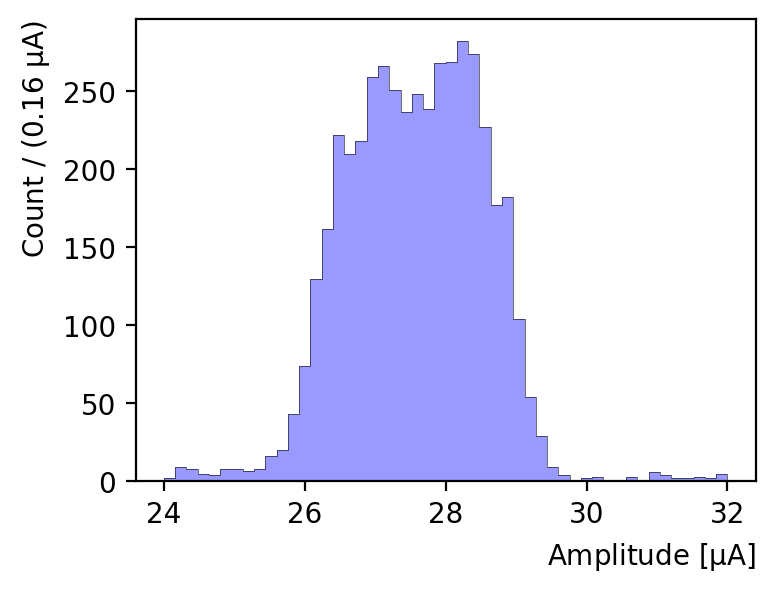

In [12]:
plt.figure(figsize=(4,3), dpi=200)
bindiff = np.round(np.diff(K_peak_bins)[0], 3)
plt.hist(K_peak_data, bins=K_peak_bins, alpha = 0.4, color = 'blue')
plt.hist(K_peak_data, bins=K_peak_bins, histtype='step', color = 'black', lw = 0.2)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / ({}".format(bindiff) + " $\mathrm{\mu A}$)")

# Let's fit the K shell peak with 3 Gaussians and a flat background

In [13]:
# make a frame
def make_frame(obs, *objects):
    frame = obs.frame()
    for obj in objects:
        obj.plotOn(frame)
    return frame

# draw a frame
def make_plot(frame):
    c = ROOT.TCanvas()
    frame.Draw()
    c.Draw()
    # need this for the plot not to be removed!
    ROOT.SetOwnership( c, False )

In [14]:
counts, bin_edges = np.histogram(K_peak_data, bins=K_peak_bins)
binWidth = np.diff(K_peak_bins)[0]
bin_centers = bin_edges[:-1] + binWidth / 2
counts_err = np.sqrt(counts)

# Observable
x = ROOT.RooRealVar("PTOFamps", "PTOFamps [uA]", 24, 32)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 26.82, 25, 28)
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", 0.53, 0.1, 1)
mean_2 = ROOT.RooRealVar("#mu2", "#mu", 28.7, 27, 30)
sigma_2 = ROOT.RooRealVar("#sigma2", "#sigma", 0.34, 0.1, 1)
mean_3 = ROOT.RooRealVar("#mu3", "#mu", 28, 27, 30)
sigma_3 = ROOT.RooRealVar("#sigma3", "#sigma", 0.48, 0.1, 1)

# Distributions
g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)
g2 = ROOT.RooGaussian("g2", "#g2", x, mean_2, sigma_2)
g3 = ROOT.RooGaussian("g3", "#g3", x, mean_3, sigma_3)
flat = ROOT.RooUniform("flat", "#flat", x)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.43, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.15, 0.0, 1.0)
frac3 = ROOT.RooRealVar("c3", "#c", 0.38, 0.0, 1.0)

# Convert numpy array into RooFit object
pdf = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, g2, g3, flat), ROOT.RooArgList(frac1, frac2, frac3))
# 
#data = ROOT.RooDataSet.from_numpy({"x": K_peak_data},[x],name='2_gauss',title='2_gauss')
data = ROOT.RooDataHist.from_numpy(counts, [x], bins=[K_peak_bins])

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         2.68200e+01  3.00000e-01    2.50000e+01  2.80000e+01
     2 #mu2         2.87000e+01  3.00000e-01    2.70000e+01  3.00000e+01
     3 #mu3         2.80000e+01  3.00000e-01    2.70000e+01  3.00000e+01
     4 #sigma1      5.30000e-01  9.00000e-02    1.00000e-01  1.00000e+00
     5 #sigma2      3.40000e-01  9.00000e-02    1.00000e-01  1.00000e+00
     6 #sigma3      4.80000e-01  9.00000e-02    1.00000e-01  1.00000e+00
     7 c1           4.30000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     8 c2           1.50000e-01  7.50000e-02    0.00000e+00  1.00000e+00
     9 c3           3.80000e-01  1.00000e-01    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 ****

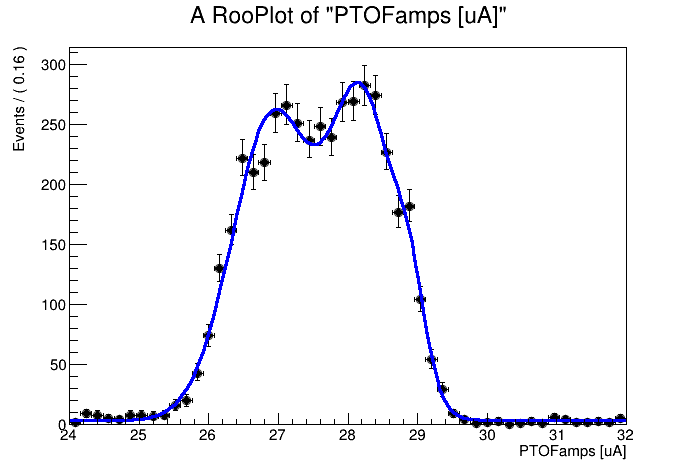

In [15]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = make_frame(x,data,pdf)

#pdf.paramOn(frame)
make_plot(frame)

In [16]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data))
sum_frac1_frac2_frac3 = ROOT.RooFormulaVar("sum_c1_c2_c3", "@0 + @1 + @2", ROOT.RooArgList(frac1, frac2, frac3))
signal = ROOT.RooProduct("event yield", "nevent * (frac1 + frac2 + frac3)", ROOT.RooArgList(nevent, sum_frac1_frac2_frac3))

print(f'The number of events in the peak is {signal.getVal():.1f} with error {signal.getPropagatedError(fit_result):.1f}')

The number of events in the peak is 4394.5 with error 20.4


In [19]:
def gauss(x, mu1, sigma1):
    return 1 / np.sqrt(2 * np.pi * sigma1**2) * np.exp( -(x - mu1)**2 / (2 * sigma1**2) )

def uniform(x, xrange):
    return 1.0 / xrange

def gauss3_flat(x, c1, c2, c3, mu1, sigma1, mu2, sigma2, mu3, sigma3, xrange):
    gauss1 = gauss(x, mu1, sigma1)
    gauss2 = gauss(x, mu2, sigma2)
    gauss3 = gauss(x, mu3, sigma3)
    flat = uniform(x, xrange)

    PDF = c1 * gauss1 + c2 * gauss2 + c3 * gauss3 + (1 - c1 - c2 - c3) * flat

    return PDF

In [20]:
x_plot = np.linspace(24, 32, 101)
mu1, mu1_err, mu2, mu2_err, mu3, mu3_err = mean_1.getVal(), mean_1.getError(), mean_2.getVal(), mean_2.getError(), mean_3.getVal(), mean_3.getError()
sigma1, sigma1_err, sigma2, sigma2_err, sigma3, sigma3_err = sigma_1.getVal(), sigma_1.getError(), sigma_2.getVal(), sigma_2.getError(), sigma_3.getVal(), sigma_3.getError()
c1, c1_err, c2, c2_err, c3, c3_err = frac1.getVal(), frac1.getError(), frac2.getVal(), frac2.getError(), frac3.getVal(), frac3.getError()
xrange = max(K_peak_bins) - min(K_peak_bins)

PDF = np.array([gauss3_flat(i, c1, c2, c3, mu1, sigma1, mu2, sigma2, mu3, sigma3, xrange) for i in x_plot])
gauss1 = np.array([gauss(i, mu1, sigma1) for i in x_plot])
gauss2 = np.array([gauss(i, mu2, sigma2) for i in x_plot])
gauss3 = np.array([gauss(i, mu3, sigma3) for i in x_plot])
flat = np.array([uniform(i, xrange) for i in x_plot])

(24.0, 31.0)

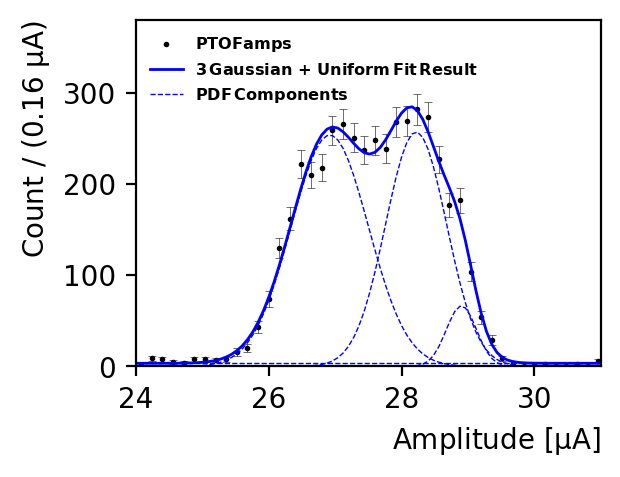

In [22]:
colors = ['#3D6CA5', '#92C0DC', '#F9965C', '#D72B22']

plt.figure(figsize=(4*0.75,3*0.75), dpi=200)
bindiff = np.round(np.diff(K_peak_bins)[0], 3)
#plt.hist(K_peak_data, bins=K_peak_bins, label = 'PTOFamps', alpha = 1)
#plt.hist(K_peak_data, bins=K_peak_bins, histtype='step', color = 'black', lw = 0.2)

plt.errorbar(bin_centers, counts, yerr = counts_err, ls = "None", color='black', capsize = 1.5, elinewidth=0.2, capthick = 0.2)
plt.scatter(bin_centers, counts, color = 'black', s = 1, label = r'$\mathbf{PTOFamps}$')

plt.plot(x_plot, PDF*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'blue', lw = 1,
         label = r'$\mathbf{3\,Gaussian\,+\,Uniform\,Fit\,Result}$')

plt.plot(x_plot, c1*gauss1*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--', label = r'$\mathbf{PDF\,Components}$')#,
#         label = r'$\mathbf{PDF_1 = c_1 Gauss_1 (\mu_1, \sigma_1)}$' + 
#           '\n' + r'$\mathrm{c_1}$ = ' + f'{ufloat(c1, c1_err):.1uS}' +
#           '\n'+ r'$\mathrm{\mu_1}$ = ' + f'{ufloat(mu1, mu1_err):.1uS} ' + r'$\mathrm{\mu A}$' + 
#           '\n' + r'$\mathrm{\sigma_1}$ = ' + f'{ufloat(sigma1, sigma1_err):.1uS} ' + r'$\mathrm{\mu A}$')
plt.plot(x_plot, c2*gauss2*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--')#,
#         label = r'$\mathbf{PDF_2 = c_2 Gauss_2 (\mu_2, \sigma_2)}$' + 
#           '\n' + r'$\mathrm{c_2}$ = ' + f'{ufloat(c2, c2_err):.1uS}' +
#           '\n'+ r'$\mathrm{\mu_2}$ = ' + f'{ufloat(mu2, mu2_err):.1uS} ' + r'$\mathrm{\mu A}$' + 
#           '\n' + r'$\mathrm{\sigma_2}$ = ' + f'{ufloat(sigma2, sigma2_err):.1uS} ' + r'$\mathrm{\mu A}$')
plt.plot(x_plot, c3*gauss3*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--')#,
#         label = r'$\mathbf{PDF_3 = c_3 Gauss_3 (\mu_3, \sigma_3)}$' + 
#           '\n' + r'$\mathrm{c_3}$ = ' + f'{ufloat(c3, c3_err):.1uS}' +
#           '\n'+ r'$\mathrm{\mu_3}$ = ' + f'{ufloat(mu3, mu3_err):.1uS} ' + r'$\mathrm{\mu A}$' + 
#           '\n' + r'$\mathrm{\sigma_3}$ = ' + f'{ufloat(sigma3, sigma3_err):.1uS} ' + r'$\mathrm{\mu A}$')
plt.plot(x_plot, (1 - c1 - c2 - c3)*flat*len(K_peak_data)*np.diff(K_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--')#,
#         label = r'$\mathbf{PDF_4 = (1-c_1-c_2-c_3)\,Uniform}$')

#plt.axvline(bin_centers[9] - binWidth / 2, 0, 0.1, lw = 0.5, color = 'black', ls = '--')
#plt.axvline(bin_centers[-8] + binWidth / 2, 0, 0.1, lw = 0.5, color = 'black', ls = '--')

plt.legend(fontsize = 5.8, loc = 'upper left')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / ({}".format(bindiff) + " $\mathrm{\mu A}$)")

plt.ylim(0, 380)
plt.xlim(24, 31)

# Let's fit the L shell peak with a Gaussian and a flat background

In [23]:
counts, bin_edges = np.histogram(L_peak_data, bins=L_peak_bins)
binWidth = np.diff(L_peak_bins)[0]
bin_centers = bin_edges[:-1] + binWidth / 2
counts_err = np.sqrt(counts)
counts_err[counts_err == 0] = np.inf

# Observable
x = ROOT.RooRealVar("x", "x", 2.5, 5)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 3.619, 2, 6)
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", 0.175, 0.1, 4)

# Distributions
g1 = ROOT.RooGaussian("g1", "g1", x, mean_1, sigma_1)
flat = ROOT.RooUniform("flat", "flat", x)

# Weights of distributions
frac1 = ROOT.RooRealVar("c1", "c", 0.87, 0.0, 1.0)

# Weighted sum of distributions
pdf = ROOT.RooAddPdf("model", "model", [g1, flat], [frac1])
# Convert numpy array into RooFit object
#data = ROOT.RooDataSet.from_numpy({"x": L_peak_data},[x],name='1_Johnson',title='1_Johnson')
data = ROOT.RooDataHist.from_numpy(counts, [x], bins=[L_peak_bins])

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         3.61900e+00  4.00000e-01    2.00000e+00  6.00000e+00
     2 #sigma1      1.75000e-01  3.75000e-02    1.00000e-01  4.00000e+00
     3 c1           8.70000e-01  6.50000e-02    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        1500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=33.5309 FROM MIGRAD    STATUS=INITIATE       12 CALLS          13 TOTAL
                     EDM= unknown      STRATEGY= 1      NO ERROR MATRIX       
  E

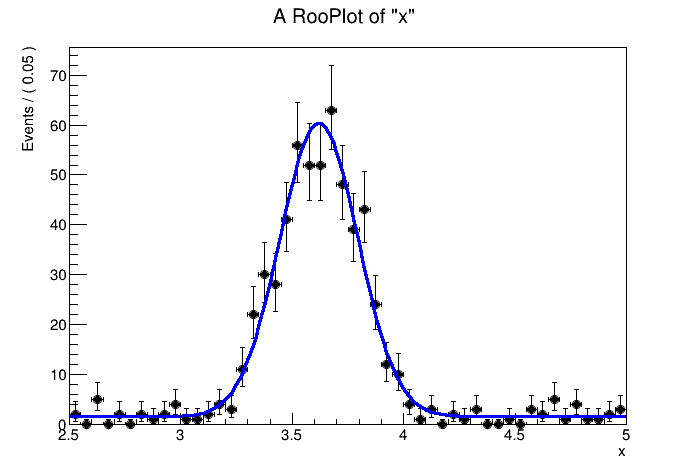

In [24]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()
fit_result = m.save()

frame = make_frame(x,data,pdf)

#pdf.paramOn(frame)
make_plot(frame)

In [25]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(L_peak_data))
signal = ROOT.RooProduct("event yield", "nevent * frac1", ROOT.RooArgList(nevent, frac1))

print(f'The number of events in the peak is {signal.getVal():.1f} with error {signal.getPropagatedError(fit_result):.1f}')

The number of events in the peak is 516.4 with error 11.1


In [26]:
def gauss_flat(x, c1, mu1, sigma1, xrange):
    gauss1 = gauss(x, mu1, sigma1)
    flat1 = uniform(x, xrange)

    PDF = c1 * gauss1 + (1 - c1) * flat1

    return PDF

In [27]:
x_plot = np.linspace(2.5, 5, 101)
mu1, mu1_err = mean_1.getVal(), mean_1.getError()
sigma1, sigma1_err = sigma_1.getVal(), sigma_1.getError()
c1, c1_err = frac1.getVal(), frac1.getError()
xrange = max(L_peak_bins) - min(L_peak_bins)

PDF = np.array([gauss_flat(i, c1, mu1, sigma1, xrange) for i in x_plot])
gauss1 = np.array([gauss(i, mu1, sigma1) for i in x_plot])
flat1 = np.array([uniform(i, xrange) for i in x_plot])

(2.5, 4.8)

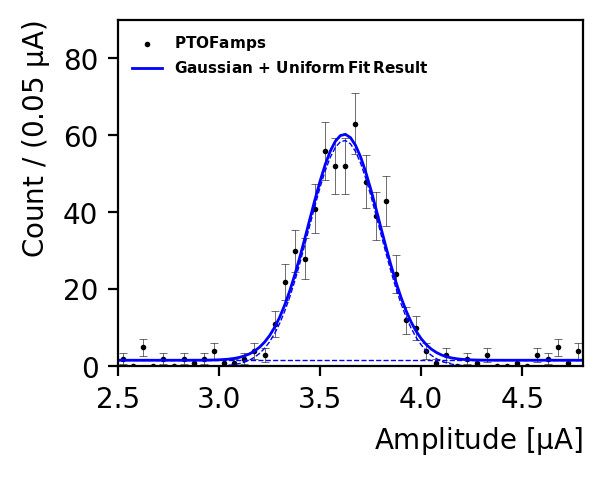

In [28]:
plt.figure(figsize=(4*0.75,3*0.75), dpi=200)
bindiff = np.round(np.diff(L_peak_bins)[0], 3)
#plt.hist(L_peak_data, bins=L_peak_bins, label = 'PTOFamps', alpha = 1)
#plt.hist(L_peak_data, bins=L_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.errorbar(bin_centers, counts, yerr = np.sqrt(counts), ls = "None", color='black', capsize = 1.5, elinewidth=0.2, capthick = 0.2)
plt.scatter(bin_centers, counts, color = 'black', s = 1, label = r'$\mathbf{PTOFamps}$')


plt.plot(x_plot, PDF*len(L_peak_data)*np.diff(L_peak_bins)[0], color = 'blue', lw = 1, label = r'$\mathbf{Gaussian\,+\,Uniform\,Fit\,Result}$')
plt.plot(x_plot, c1*gauss1*len(L_peak_data)*np.diff(L_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--')
plt.plot(x_plot, (1-c1)*flat1*len(L_peak_data)*np.diff(L_peak_bins)[0], color = 'blue', lw = 0.5, ls = '--')

#plt.axvline(bin_centers[6] - binWidth / 2, 0, 0.15, lw = 0.5, color = 'black', ls='--')
#plt.axvline(bin_centers[-23] + binWidth / 2, 0, 0.15, lw = 0.5, color = 'black', ls='--')

plt.legend(fontsize = 5.5, loc = 'upper left')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / ({}".format(bindiff) + " $\mathrm{\mu A}$)")

plt.ylim(0, 90)
plt.xlim(2.5, 4.8)